## Introduction to IsaacLab

The purpose of this project is to create a pathway for people who want to learn how to create custom drone environments using NVIDIA's Isaac Lab and Isaac Sim. Before getting started, you must install the isaaclab. You can install it locally from [here](https://isaac-sim.github.io/IsaacLab/main/source/setup/installation/index.html) or you can deploy its containers from [here](https://isaac-sim.github.io/IsaacLab/main/source/deployment/index.html). For more information you can go to the [IsaacLab Repostry](https://isaac-sim.github.io/IsaacLab/main/index.html).

---

### Libraries

**Isaac-Sim**: The platform that all the physics simulation runs on. It is Nvidia's PhysX engine and it runs on GPU.

**Isaac-Lab**: The toolkit that is build on top of Isaac-Sim. It build specificaly for robot learning.

**rsl_rl**: The learning library that contains neural network and PPO(Proximal Policy Optimzation) alghorithm. 


---

### The Reinforcement-Learning Loop

In RL Loop, drone takes and action. Then, drone's actions get gets scored. Finally, neural network nudges itself in order to score higher next time. Drones brain gets modified and decides the next action.

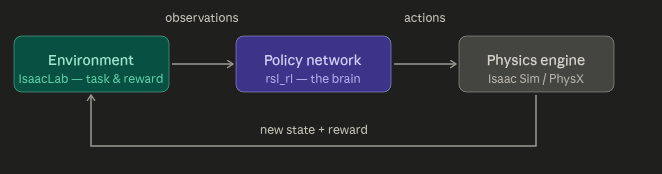

After each episode, environment gets resetted.

---

### Launching An Empty Simulation

Open a terminal and run:
```bash
python3 empty-simulation.py
```

```python
import argparse
from isaaclab.app import AppLauncher

# Parse the arguments
parser = argparse.ArgumentParser(description="This is an empty simulation")
AppLauncher.add_app_launcher_args(parser)
args_cli = parser.parse_args()

# This must be initialized before importng the lbrary
app_launcher = AppLauncher(args_cli)
simulation_app = app_launcher.app

# ---After Launch---
import isaaclab.sim as sim_utils
from isaaclab.assets import Articulation
from isaaclab.sim import SimulationCfg, SimulationContext
from isaaclab_assets import CRAZYFLIE_CFG

def create_scene():

    # The Ground plane
    ground_config = sim_utils.GroundPlaneCfg()
    ground_config.func("/World/ground", ground_config)

    # The Lignt
    light_config = sim_utils.DomeLightCfg(intensity=3000.0)
    light_config.func("/World/Light", light_config)

def drone_object():

    # The Drone
    drone_config = CRAZYFLIE_CFG.replace(prim_path="/World/Crazyflie")
    drone_config.init_state.pos = (0.0, 0.0, 0.5)
    drone = Articulation(drone_config)
    return drone

def main():

    # The Simulation
    simulation_config = SimulationCfg(dt=0.01)
    simulation = SimulationContext(simulation_config)
    simulation.set_camera_view(eye=[2.0, 2.0, 1.5], target=[0.0, 0.0, 0.3])

    create_scene()
    drone = drone_object()
    simulation.reset()
    print("Simulation Started")

    while simulation_app.is_running():
        simulation.step()
        drone.update(simulation_config.dt)

if __name__=="__main__":
    main()
    simulation_app.close()
```

**`AppLauncher`**: It contains CLI arguments such as: *--headless*.

**`isaaclab.sim`**: It enables us to interact/create simulation elements such as: *ground_plane*.

**`Articulation`**: It is the interface for managing and simulating drone structures. 

**`SimulationCfg`**: It is the main configuration class for interacting with physics simulation.

**`SimulationContext`**: It controls the entire simulation(loop, scene, coordinates).

**`isaaclab_assets`**: It stores ready-to-use robot configurations and USD files.